In [ ]:
symbol = "UPRO"

In [ ]:
import pandas as pd

df = pd.read_csv(f'../data/{symbol}_5min.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.reset_index(drop=True)

# Start with df copy to maintain same index
features = df[['timestamp', 'close']].copy()

# Add 10 historical closes
for i in range(1, 11):
    features[f'close_lag_{i}'] = df['close'].shift(i)

# Normalize all price columns by current close
price_cols = ['close'] + [f'close_lag_{i}' for i in range(1, 11)]
features[price_cols] = features[price_cols].div(features['close'], axis=0)

features

In [4]:
# Calculate multiple targets with different parameters
# Modify these lists to create different target columns
loss_pcts = [0.01, 0.02, 0.05, 0.10]  # Percentage prices go down (e.g., 0.05 = 5% loss)
profit_pcts = [0.01, 0.05, 0.025, 0.10, 0.15]  # Percentage prices go up (e.g., 0.10 = 10% profit)
lookahead_periods = [144, 288]  # Number of 5-min periods (e.g., 288 = 24 hours)

def calc_target(idx, loss_pct, profit_pct, lookahead):
    if idx >= len(df) - lookahead: 
        return 0
    c = df['close'].iloc[idx]
    f = df['close'].iloc[idx+1:idx+1+lookahead].values
    h, l = f >= c * (1 + profit_pct), f <= c * (1 - loss_pct)
    if not h.any(): return 0
    if not l.any(): return 1
    return 1 if h.argmax() < l.argmax() else 0

# Generate all target columns
for loss_pct in loss_pcts:
    for profit_pct in profit_pcts:
        for lookahead in lookahead_periods:
            col_name = f'target_L{int(loss_pct*100)}_P{int(profit_pct*100)}_H{lookahead}'
            df[col_name] = [calc_target(i, loss_pct, profit_pct, lookahead) for i in range(len(df))]
            features[col_name] = df[col_name]
            print(f"{col_name}: {df[col_name].value_counts().to_dict()}")

features

target_L1_P5_H144: {0: 156525, 1: 7516}
target_L1_P5_H288: {0: 147899, 1: 16142}
target_L1_P2_H144: {0: 130736, 1: 33305}
target_L1_P2_H288: {0: 118751, 1: 45290}
target_L1_P10_H144: {0: 163345, 1: 696}
target_L1_P10_H288: {0: 161721, 1: 2320}
target_L1_P15_H144: {0: 163919, 1: 122}
target_L1_P15_H288: {0: 163584, 1: 457}
target_L2_P1_H144: {1: 93809, 0: 70232}
target_L2_P1_H288: {1: 105060, 0: 58981}
target_L2_P5_H144: {0: 154752, 1: 9289}
target_L2_P5_H288: {0: 143106, 1: 20935}
target_L2_P2_H144: {0: 124209, 1: 39832}
target_L2_P2_H288: {0: 105900, 1: 58141}
target_L2_P10_H144: {0: 163204, 1: 837}
target_L2_P10_H288: {0: 161097, 1: 2944}
target_L2_P15_H144: {0: 163896, 1: 145}
target_L2_P15_H288: {0: 163466, 1: 575}
target_L5_P1_H144: {1: 100933, 0: 63108}
target_L5_P1_H288: {1: 119270, 0: 44771}
target_L5_P5_H144: {0: 153722, 1: 10319}
target_L5_P5_H288: {0: 139054, 1: 24987}
target_L5_P2_H144: {0: 120159, 1: 43882}
target_L5_P2_H288: {0: 95908, 1: 68133}
target_L5_P10_H144: {0: 16

,timestamp,close,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5,close_lag_6,close_lag_7,close_lag_8,...,target_L10_P1_H144,target_L10_P1_H288,target_L10_P5_H144,target_L10_P5_H288,target_L10_P2_H144,target_L10_P2_H288,target_L10_P10_H144,target_L10_P10_H288,target_L10_P15_H144,target_L10_P15_H288
0,2022-01-03 09:05:00+00:00,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,0,0,0,0,0,0
1,2022-01-03 09:10:00+00:00,1.0,1.000260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,0,0,0,0,0,0
2,2022-01-03 09:15:00+00:00,1.0,0.997797,0.998056,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,0,0,0,0,0,0
3,2022-01-03 09:20:00+00:00,1.0,1.000000,0.997797,0.998056,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,0,0,0,0,0,0
4,2022-01-03 09:25:00+00:00,1.0,1.000519,1.000519,0.998315,0.998574,NaN,NaN,NaN,NaN,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164036,2025-11-19 23:45:00+00:00,1.0,1.000544,0.999094,0.997832,0.996918,0.996918,0.998731,0.997099,0.994199,...,0,0,0,0,0,0,0,0,0,0
164037,2025-11-19 23:50:00+00:00,1.0,0.998371,0.998914,0.997466,0.996206,0.995294,0.995294,0.997104,0.995475,...,0,0,0,0,0,0,0,0,0,0
164038,2025-11-19 23:55:00+00:00,1.0,0.999819,0.998190,0.998733,0.997286,0.996026,0.995114,0.995114,0.996924,...,0,0,0,0,0,0,0,0,0,0
164039,2025-11-20 00:00:00+00:00,1.0,0.998464,0.998283,0.996657,0.997199,0.995754,0.994496,0.993586,0.993586,...,0,0,0,0,0,0,0,0,0,0


In [5]:
import talib as ta

# Calculate technical indicators from original df
h, l, c, v = df['high'].values, df['low'].values, df['close'].values, df['volume'].values

# Trend indicators
features['sma_10'] = ta.SMA(c, 10)
features['sma_20'] = ta.SMA(c, 20)
features['ema_10'] = ta.EMA(c, 10)
features['ema_20'] = ta.EMA(c, 20)
features['adx'] = ta.ADX(h, l, c, 14)

# Momentum indicators
features['rsi'] = ta.RSI(c, 14)
features['cci'] = ta.CCI(h, l, c, 14)
features['willr'] = ta.WILLR(h, l, c, 14)
features['mfi'] = ta.MFI(h, l, c, v, 14)
features['roc'] = ta.ROC(c, 10)

# MACD
features['macd'], features['macd_signal'], features['macd_hist'] = ta.MACD(c, 12, 26, 9)

# Bollinger Bands
features['bb_upper'], features['bb_middle'], features['bb_lower'] = ta.BBANDS(c, 20)

# Stochastic
features['stoch_k'], features['stoch_d'] = ta.STOCH(h, l, c, 14, 3, 3)

# Volatility
features['atr'] = ta.ATR(h, l, c, 14)

# Volume
features['obv'] = ta.OBV(c, v)
features['ad'] = ta.AD(h, l, c, v)

features

,timestamp,close,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5,close_lag_6,close_lag_7,close_lag_8,...,macd_signal,macd_hist,bb_upper,bb_middle,bb_lower,stoch_k,stoch_d,atr,obv,ad
0,2022-01-03 09:05:00+00:00,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7214.0,-7.214000e+03
1,2022-01-03 09:10:00+00:00,1.0,1.000260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6748.0,-7.214000e+03
2,2022-01-03 09:15:00+00:00,1.0,0.997797,0.998056,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8914.0,-5.048000e+03
3,2022-01-03 09:20:00+00:00,1.0,1.000000,0.997797,0.998056,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8914.0,-5.048000e+03
4,2022-01-03 09:25:00+00:00,1.0,1.000519,1.000519,0.998315,0.998574,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8712.0,-5.048000e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164036,2025-11-19 23:45:00+00:00,1.0,1.000544,0.999094,0.997832,0.996918,0.996918,0.998731,0.997099,0.994199,...,0.499303,0.038877,110.617738,109.51154,108.405342,94.898659,96.541297,0.292580,35732670.0,1.176538e+08
164037,2025-11-19 23:50:00+00:00,1.0,0.998371,0.998914,0.997466,0.996206,0.995294,0.995294,0.997104,0.995475,...,0.508935,0.038528,110.745958,109.58654,108.427122,98.933228,97.686983,0.284539,35733823.0,1.176550e+08
164038,2025-11-19 23:55:00+00:00,1.0,0.999819,0.998190,0.998733,0.997286,0.996026,0.995114,0.995114,0.996924,...,0.517167,0.032927,110.866879,109.64854,108.430201,99.366765,97.732884,0.268500,35736054.0,1.176557e+08
164039,2025-11-20 00:00:00+00:00,1.0,0.998464,0.998283,0.996657,0.997199,0.995754,0.994496,0.993586,0.993586,...,0.525622,0.033824,111.004345,109.72104,108.437735,100.194657,99.498217,0.261465,35738199.0,1.176579e+08


In [6]:
# Calculate slope (rate of change) for all indicators
indicators = ['sma_10', 'sma_20', 'ema_10', 'ema_20', 'adx', 'rsi', 'cci', 'willr', 
              'mfi', 'roc', 'macd', 'macd_signal', 'macd_hist', 'bb_upper', 'bb_middle', 
              'bb_lower', 'stoch_k', 'stoch_d', 'atr', 'obv', 'ad']

for ind in indicators:
    # 1-period slope: (current - previous) / previous
    prev_1 = features[ind].shift(1)
    features[f'{ind}_slope_1'] = (features[ind] - prev_1) / prev_1
    
    # 5-period slope: (current - 5th previous) / 5th previous
    prev_5 = features[ind].shift(5)
    features[f'{ind}_slope_5'] = (features[ind] - prev_5) / prev_5
    
    # Ratio: 1-period slope / 5-period slope
    features[f'{ind}_slope_ratio'] = features[f'{ind}_slope_1'] / features[f'{ind}_slope_5']

features

C:\Users\pablo\AppData\Local\Temp\ipykernel_74044\3649174220.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'{ind}_slope_5'] = (features[ind] - prev_5) / prev_5
C:\Users\pablo\AppData\Local\Temp\ipykernel_74044\3649174220.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'{ind}_slope_ratio'] = features[f'{ind}_slope_1'] / features[f'{ind}_slope_5']
C:\Users\pablo\AppData\Local\Temp\ipykernel_74044\3649174220.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

,timestamp,close,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5,close_lag_6,close_lag_7,close_lag_8,...,stoch_d_slope_ratio,atr_slope_1,atr_slope_5,atr_slope_ratio,obv_slope_1,obv_slope_5,obv_slope_ratio,ad_slope_1,ad_slope_5,ad_slope_ratio
0,2022-01-03 09:05:00+00:00,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-03 09:10:00+00:00,1.0,1.000260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.064597,NaN,NaN,-0.000000,NaN,NaN
2,2022-01-03 09:15:00+00:00,1.0,0.997797,0.998056,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.320984,NaN,NaN,-0.300250,NaN,NaN
3,2022-01-03 09:20:00+00:00,1.0,1.000000,0.997797,0.998056,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,-0.000000,NaN,NaN
4,2022-01-03 09:25:00+00:00,1.0,1.000519,1.000519,0.998315,0.998574,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.022661,NaN,NaN,-0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164036,2025-11-19 23:45:00+00:00,1.0,1.000544,0.999094,0.997832,0.996918,0.996918,0.998731,0.997099,0.994199,...,-2.456163,-0.040992,-0.175563,0.233491,-0.000079,0.000748,-0.105852,-0.000024,0.000075,-0.322283
164037,2025-11-19 23:50:00+00:00,1.0,0.998371,0.998914,0.997466,0.996206,0.995294,0.995294,0.997104,0.995475,...,0.211268,-0.027485,-0.153069,0.179557,0.000032,0.000780,0.041359,0.000010,0.000080,0.122940
164038,2025-11-19 23:55:00+00:00,1.0,0.999819,0.998190,0.998733,0.997286,0.996026,0.995114,0.995114,0.996924,...,0.003892,-0.056367,-0.173579,0.324731,0.000062,0.000175,0.356977,0.000006,0.000038,0.164857
164039,2025-11-20 00:00:00+00:00,1.0,0.998464,0.998283,0.996657,0.997199,0.995754,0.994496,0.993586,0.993586,...,0.155027,-0.026204,-0.160982,0.162775,0.000060,0.000153,0.392893,0.000018,0.000032,0.576474


In [7]:
features

,timestamp,close,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5,close_lag_6,close_lag_7,close_lag_8,...,stoch_d_slope_ratio,atr_slope_1,atr_slope_5,atr_slope_ratio,obv_slope_1,obv_slope_5,obv_slope_ratio,ad_slope_1,ad_slope_5,ad_slope_ratio
0,2022-01-03 09:05:00+00:00,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-03 09:10:00+00:00,1.0,1.000260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.064597,NaN,NaN,-0.000000,NaN,NaN
2,2022-01-03 09:15:00+00:00,1.0,0.997797,0.998056,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.320984,NaN,NaN,-0.300250,NaN,NaN
3,2022-01-03 09:20:00+00:00,1.0,1.000000,0.997797,0.998056,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,-0.000000,NaN,NaN
4,2022-01-03 09:25:00+00:00,1.0,1.000519,1.000519,0.998315,0.998574,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.022661,NaN,NaN,-0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164036,2025-11-19 23:45:00+00:00,1.0,1.000544,0.999094,0.997832,0.996918,0.996918,0.998731,0.997099,0.994199,...,-2.456163,-0.040992,-0.175563,0.233491,-0.000079,0.000748,-0.105852,-0.000024,0.000075,-0.322283
164037,2025-11-19 23:50:00+00:00,1.0,0.998371,0.998914,0.997466,0.996206,0.995294,0.995294,0.997104,0.995475,...,0.211268,-0.027485,-0.153069,0.179557,0.000032,0.000780,0.041359,0.000010,0.000080,0.122940
164038,2025-11-19 23:55:00+00:00,1.0,0.999819,0.998190,0.998733,0.997286,0.996026,0.995114,0.995114,0.996924,...,0.003892,-0.056367,-0.173579,0.324731,0.000062,0.000175,0.356977,0.000006,0.000038,0.164857
164039,2025-11-20 00:00:00+00:00,1.0,0.998464,0.998283,0.996657,0.997199,0.995754,0.994496,0.993586,0.993586,...,0.155027,-0.026204,-0.160982,0.162775,0.000060,0.000153,0.392893,0.000018,0.000032,0.576474


In [8]:
# Add lagged features for all technical indicators (normalized by current value)
indicators = ['sma_10', 'sma_20', 'ema_10', 'ema_20', 'adx', 'rsi', 'cci', 'willr', 
              'mfi', 'roc', 'macd', 'macd_signal', 'macd_hist', 'bb_upper', 'bb_middle', 
              'bb_lower', 'stoch_k', 'stoch_d', 'atr', 'obv', 'ad']

for ind in indicators:
    for lag in range(1, 10):
        features[f'{ind}_lag_{lag}'] = features[ind].shift(lag) / features[ind]

# Drop all NaN rows
features = features.dropna()

# CRITICAL: Remove last 288 rows (24h) where target cannot be properly calculated
# These rows have insufficient future data for target calculation
original_len = len(features)
features = features.iloc[:-288]
print(f"Removed last 288 rows (24h) with insufficient future data: {original_len} -> {len(features)} rows")

features

C:\Users\pablo\AppData\Local\Temp\ipykernel_74044\1596020267.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'{ind}_lag_{lag}'] = features[ind].shift(lag) / features[ind]
C:\Users\pablo\AppData\Local\Temp\ipykernel_74044\1596020267.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'{ind}_lag_{lag}'] = features[ind].shift(lag) / features[ind]
C:\Users\pablo\AppData\Local\Temp\ipykernel_74044\1596020267.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame

Removed last 288 rows (24h) with insufficient future data: 156285 -> 155997 rows


,timestamp,close,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5,close_lag_6,close_lag_7,close_lag_8,...,obv_lag_9,ad_lag_1,ad_lag_2,ad_lag_3,ad_lag_4,ad_lag_5,ad_lag_6,ad_lag_7,ad_lag_8,ad_lag_9
42,2022-01-03 13:30:00+00:00,1.0,0.999871,0.999871,1.000646,1.000258,1.000775,1.000646,1.001162,1.000129,...,-0.459657,1.000000,1.000000,0.960778,0.985434,0.976166,0.664217,0.618421,0.584075,0.489059
43,2022-01-03 13:35:00+00:00,1.0,1.000646,1.000517,1.000517,1.001292,1.000905,1.001421,1.001292,1.001809,...,3.103698,0.720208,0.720208,0.720208,0.691959,0.709717,0.703042,0.478374,0.445392,0.420655
44,2022-01-03 13:40:00+00:00,1.0,0.999613,1.000258,1.000129,1.000129,1.000904,1.000517,1.001033,1.000904,...,2.888549,1.000000,0.720208,0.720208,0.720208,0.691959,0.709717,0.703042,0.478374,0.445392
45,2022-01-03 13:45:00+00:00,1.0,1.000776,1.000388,1.001034,1.000905,1.000905,1.001680,1.001293,1.001810,...,2.315594,0.973875,0.973875,0.701392,0.701392,0.701392,0.673882,0.691176,0.684676,0.465877
46,2022-01-03 13:50:00+00:00,1.0,0.999483,1.000258,0.999871,1.000517,1.000388,1.000388,1.001163,1.000775,...,7.273627,1.071195,1.043210,1.043210,0.751328,0.751328,0.751328,0.721859,0.740384,0.733421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163736,2025-11-18 14:00:00+00:00,1.0,1.001304,0.999069,0.998510,0.998696,1.000373,0.997951,0.998975,0.998882,...,0.999881,1.000017,0.999972,0.999964,0.999977,0.999994,1.000041,1.000068,1.000052,1.000124
163737,2025-11-18 14:05:00+00:00,1.0,0.999628,1.000931,0.998696,0.998138,0.998324,1.000000,0.997579,0.998603,...,0.999590,1.000000,1.000017,0.999972,0.999964,0.999977,0.999994,1.000041,1.000068,1.000052
163738,2025-11-18 14:10:00+00:00,1.0,0.999535,0.999162,1.000465,0.998232,0.997673,0.997859,0.999535,0.997115,...,0.999570,0.999973,0.999972,0.999990,0.999944,0.999937,0.999950,0.999966,1.000014,1.000041
163739,2025-11-18 14:15:00+00:00,1.0,1.001771,1.001305,1.000932,1.002238,1.000000,0.999441,0.999627,1.001305,...,0.999581,1.000009,0.999982,0.999982,0.999999,0.999953,0.999946,0.999959,0.999975,1.000023


In [9]:
# IMPORTANT: Sort by timestamp first to ensure proper chronological split
features = features.sort_values('timestamp').reset_index(drop=True)

# Split into train (75%) and validation (25%) by timestamp
split_idx = int(len(features) * 0.75)
train = features.iloc[:split_idx].copy()
val = features.iloc[split_idx:].copy()
full = features.copy()

# Verify temporal split integrity
train_max_ts = pd.to_datetime(train['timestamp'], utc=True).max()
val_min_ts = pd.to_datetime(val['timestamp'], utc=True).min()
val_max_ts = pd.to_datetime(val['timestamp'], utc=True).max()

print("=== TEMPORAL SPLIT VERIFICATION ===")
print(f"Train set: {len(train)} rows")
print(f"  Oldest: {pd.to_datetime(train['timestamp'], utc=True).min()}")
print(f"  Newest: {train_max_ts}")
print(f"\nValidation set: {len(val)} rows")
print(f"  Oldest: {val_min_ts}")
print(f"  Newest: {val_max_ts}")
print(f"\nTime gap: {val_min_ts - train_max_ts}")

# Assert no temporal leakage
assert train_max_ts < val_min_ts, "ERROR: Training data contains timestamps newer than validation data!"
print("\n✓ Temporal split verified - no leakage detected")

# Format timestamp as ISO 8601 (handle timezone-aware datetimes)
train['timestamp'] = pd.to_datetime(train['timestamp'], utc=True).dt.strftime('%Y-%m-%dT%H:%M:%S')
val['timestamp'] = pd.to_datetime(val['timestamp'], utc=True).dt.strftime('%Y-%m-%dT%H:%M:%S')
full['timestamp'] = pd.to_datetime(full['timestamp'], utc=True).dt.strftime('%Y-%m-%dT%H:%M:%S')

train.to_csv(f'../data/ml/{symbol}_5min_ml_train.csv', index=False)
val.to_csv(f'../data/ml/{symbol}_5min_ml_val.csv', index=False)
full.to_csv(f'../data/ml/{symbol}_5min_ml_full.csv', index=False)

print(f"\nSaved {len(train)} rows to data/ml/{symbol}_5min_ml_train.csv")
print(f"Saved {len(val)} rows to data/ml/{symbol}_5min_ml_val.csv")
print(f"Saved {len(full)} rows to data/ml/{symbol}_5min_ml_full.csv")

=== TEMPORAL SPLIT VERIFICATION ===
Train set: 116997 rows
  Oldest: 2022-01-03 13:30:00+00:00
  Newest: 2024-12-09 19:40:00+00:00

Validation set: 39000 rows
  Oldest: 2024-12-09 19:45:00+00:00
  Newest: 2025-11-18 14:20:00+00:00

Time gap: 0 days 00:05:00

✓ Temporal split verified - no leakage detected

Saved 116997 rows to data/ml/UPRO_5min_ml_train.csv
Saved 39000 rows to data/ml/UPRO_5min_ml_val.csv
Saved 155997 rows to data/ml/UPRO_5min_ml_full.csv


In [10]:
features['target_L1_P1_H144'].value_counts()

target_L1_P1_H144
0    80029
1    75968
Name: count, dtype: int64

In [ ]:
# Model training with hyperparameter optimization
import xgboost as xgb
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# PARAMETERS
target_column = 'target_L5_P10_H288' # Threshold for converting probabilities to predictions (0-1)

# Check GPU availability
try:
    import torch
    use_gpu = torch.cuda.is_available()
    if use_gpu:
        print(f"GPU detected: {torch.cuda.get_device_name(0)}")
except:
    use_gpu = False

# Modern XGBoost (2.0+) uses device='cuda' with tree_method='hist'
tree_method = 'hist'
device = 'cuda' if use_gpu else 'cpu'
print(f"Using device: {device}, tree_method: {tree_method}")
print(f"Prediction threshold: {prediction_threshold}\n")

# Prepare data: remove all target columns except the one we're using
target_cols = [col for col in features.columns if col.startswith('target')]
other_targets = [col for col in target_cols if col != target_column]
df_model = features.drop(columns=other_targets)

# Clean data: replace inf and NaN values
print(f"Before cleaning - inf values: {np.isinf(df_model.select_dtypes(include=[np.number])).sum().sum()}")
print(f"Before cleaning - NaN values: {df_model.isna().sum().sum()}")

# Replace inf with NaN, then drop rows with NaN
df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna()

print(f"After cleaning - Rows remaining: {len(df_model)}")

# Sort by timestamp to ensure proper temporal split
df_model = df_model.sort_values('timestamp').reset_index(drop=True)

# Split at 70% cutoff by timestamp
split_idx = int(len(df_model) * 0.70)
train_df = df_model.iloc[:split_idx].copy()
val_df = df_model.iloc[split_idx:].copy()

print(f"\nTrain: {len(train_df)} rows, Val: {len(val_df)} rows")
print(f"Train dates: {train_df['timestamp'].min()} to {train_df['timestamp'].max()}")
print(f"Val dates: {val_df['timestamp'].min()} to {val_df['timestamp'].max()}")

# Prepare features and target
feature_cols = [col for col in df_model.columns if col not in ['timestamp', target_column]]
X_train = train_df[feature_cols]
y_train = train_df[target_column]
X_val = val_df[feature_cols]
y_val = val_df[target_column]

print(f"\nTraining target distribution: {y_train.value_counts().to_dict()}")
print(f"Validation target distribution: {y_val.value_counts().to_dict()}")

# Bayesian optimization search space (gradient-based optimization)
search_spaces = {
    'max_depth': Integer(3, 30),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'n_estimators': Integer(100, 5000),
    'min_child_weight': Integer(1, 5),
    'gamma': Real(0.0, 0.2, prior='uniform'),
    'subsample': Real(0.7, 1.0, prior='uniform'),
    'colsample_bytree': Real(0.7, 1.0, prior='uniform'),
    'scale_pos_weight': Real(1.0, sum(y_train == 0) / sum(y_train == 1), prior='uniform')
}

# Bayesian search with gradient-based optimization
xgb_model = xgb.XGBClassifier(
    random_state=42, 
    tree_method=tree_method,
    device=device,
    eval_metric='logloss'
)
bayes_search = BayesSearchCV(
    xgb_model, 
    search_spaces, 
    n_iter=50,
    cv=3, 
    scoring='precision',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\nStarting Bayesian hyperparameter optimization (optimizing for precision)...")
bayes_search.fit(X_train, y_train)

# Best model
best_model = bayes_search.best_estimator_
print(f"\nBest parameters: {bayes_search.best_params_}")
print(f"Best CV Precision: {bayes_search.best_score_:.4f}")



=== TRAINING METRICS ===
Threshold: 0.038
Accuracy: 0.7336
Precision: 0.0876
Recall: 1.0000
F1: 0.1610

              precision    recall  f1-score   support

           0       1.00      0.73      0.84     93159
           1       0.09      1.00      0.16      2444

    accuracy                           0.73     95603
   macro avg       0.54      0.86      0.50     95603
weighted avg       0.98      0.73      0.82     95603


=== VALIDATION METRICS ===
Threshold: 0.038
Accuracy: 0.8966
Precision: 0.0851
Recall: 0.4716
F1: 0.1442

              precision    recall  f1-score   support

           0       0.99      0.90      0.94     40216
           1       0.09      0.47      0.14       757

    accuracy                           0.90     40973
   macro avg       0.54      0.69      0.54     40973
weighted avg       0.97      0.90      0.93     40973



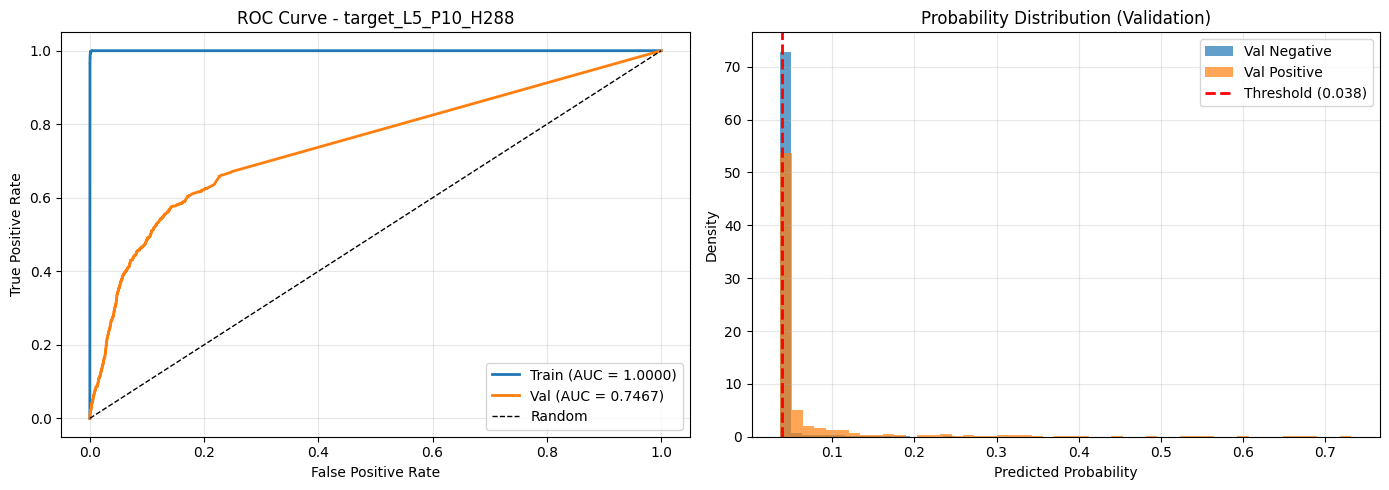

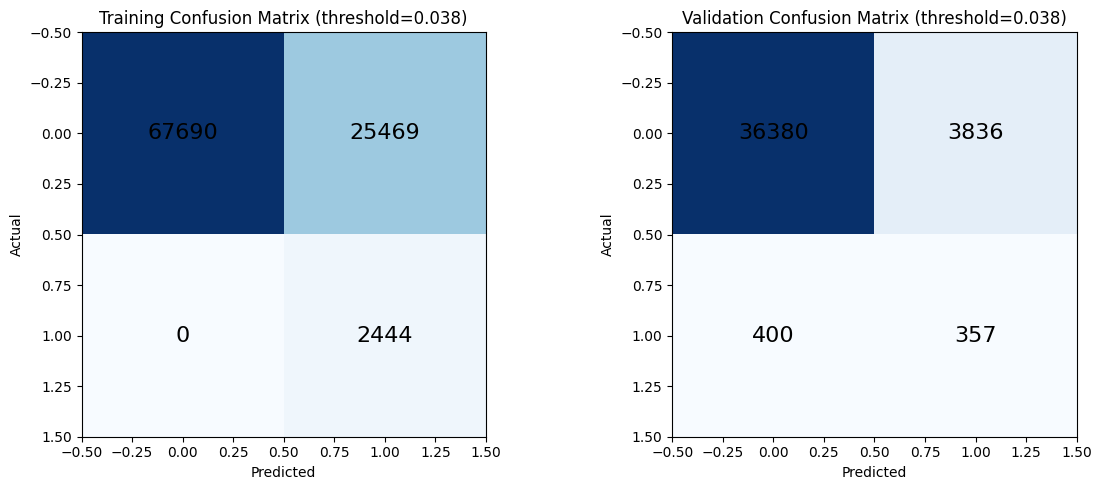

In [23]:
prediction_threshold = 0.038

# Get probability predictions
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_val_proba = best_model.predict_proba(X_val)[:, 1]

# Apply custom threshold to get binary predictions
y_train_pred = (y_train_proba >= prediction_threshold).astype(int)
y_val_pred = (y_val_proba >= prediction_threshold).astype(int)

# Metrics
print("\n=== TRAINING METRICS ===")
print(f"Threshold: {prediction_threshold}")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"F1: {f1_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"\n{classification_report(y_train, y_train_pred, zero_division=0)}")

print("\n=== VALIDATION METRICS ===")
print(f"Threshold: {prediction_threshold}")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred, zero_division=0):.4f}")
print(f"F1: {f1_score(y_val, y_val_pred, zero_division=0):.4f}")
print(f"\n{classification_report(y_val, y_val_pred, zero_division=0)}")

# Plot ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_val = auc(fpr_val, tpr_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr_train, tpr_train, label=f'Train (AUC = {roc_auc_train:.4f})', linewidth=2)
axes[0].plot(fpr_val, tpr_val, label=f'Val (AUC = {roc_auc_val:.4f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve - {target_column}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Probability distribution (validation only)
axes[1].hist(y_val_proba[y_val == 0], bins=50, alpha=0.7, label='Val Negative', density=True)
axes[1].hist(y_val_proba[y_val == 1], bins=50, alpha=0.7, label='Val Positive', density=True)
axes[1].axvline(x=prediction_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({prediction_threshold})')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Probability Distribution (Validation)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(y_train, y_train_pred)
cm_val = confusion_matrix(y_val, y_val_pred)

im1 = axes[0].imshow(cm_train, cmap='Blues')
axes[0].set_title(f'Training Confusion Matrix (threshold={prediction_threshold})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_train[i, j], ha='center', va='center', fontsize=16)

im2 = axes[1].imshow(cm_val, cmap='Blues')
axes[1].set_title(f'Validation Confusion Matrix (threshold={prediction_threshold})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm_val[i, j], ha='center', va='center', fontsize=16)

plt.tight_layout()
plt.show()


=== VALIDATION METRICS ===
Threshold: 0.03
Precision: 0.0185
Recall: 1.0000


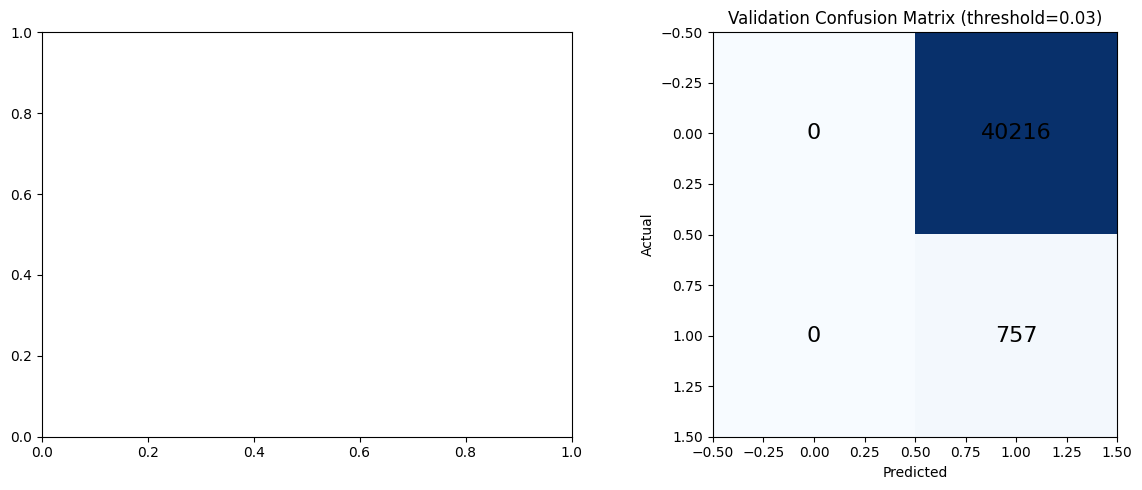


=== VALIDATION METRICS ===
Threshold: 0.04
Precision: 0.1029
Recall: 0.4122


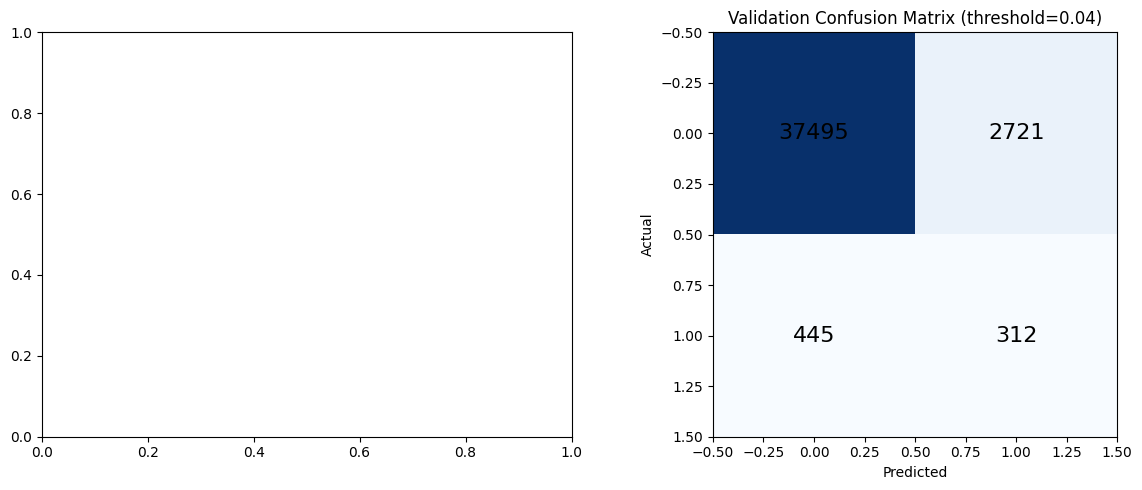


=== VALIDATION METRICS ===
Threshold: 0.05
Precision: 0.1173
Recall: 0.2576


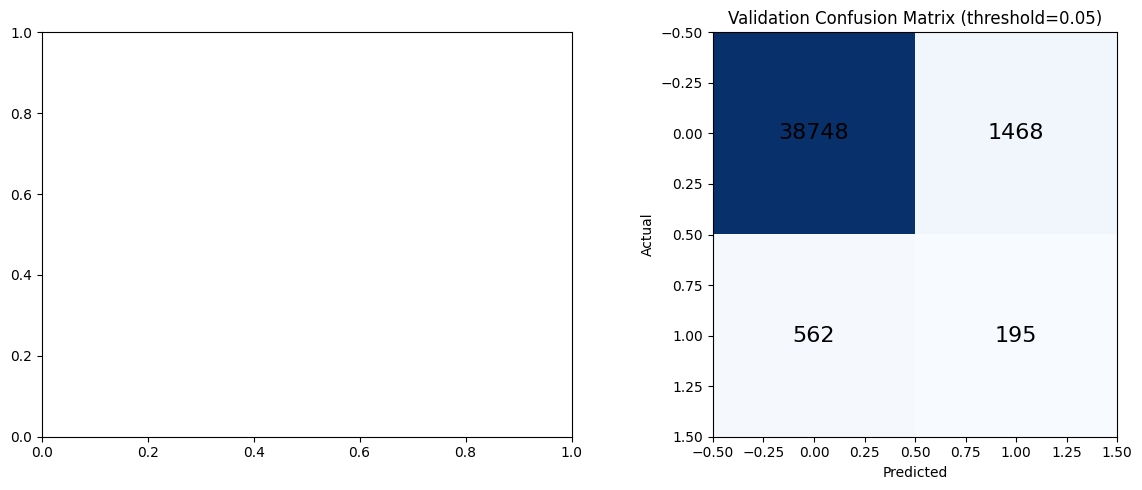


=== VALIDATION METRICS ===
Threshold: 0.06
Precision: 0.1164
Recall: 0.2034


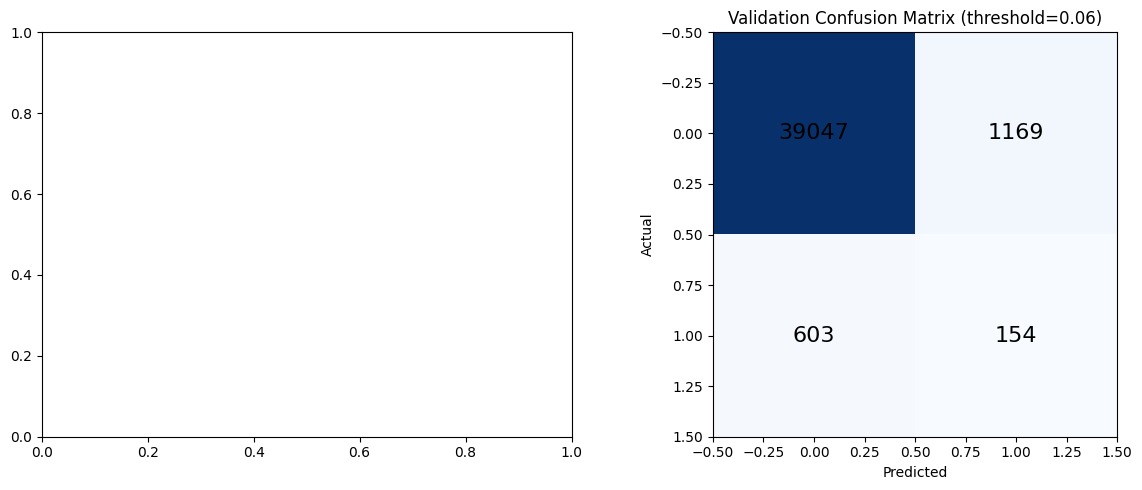


=== VALIDATION METRICS ===
Threshold: 0.08
Precision: 0.1066
Recall: 0.1480


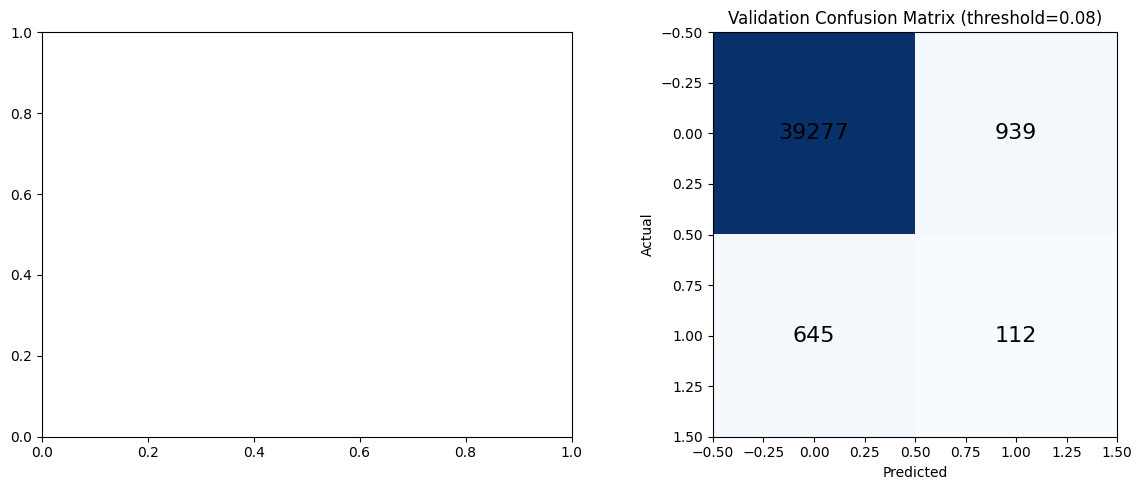


=== VALIDATION METRICS ===
Threshold: 0.1
Precision: 0.1089
Recall: 0.1202


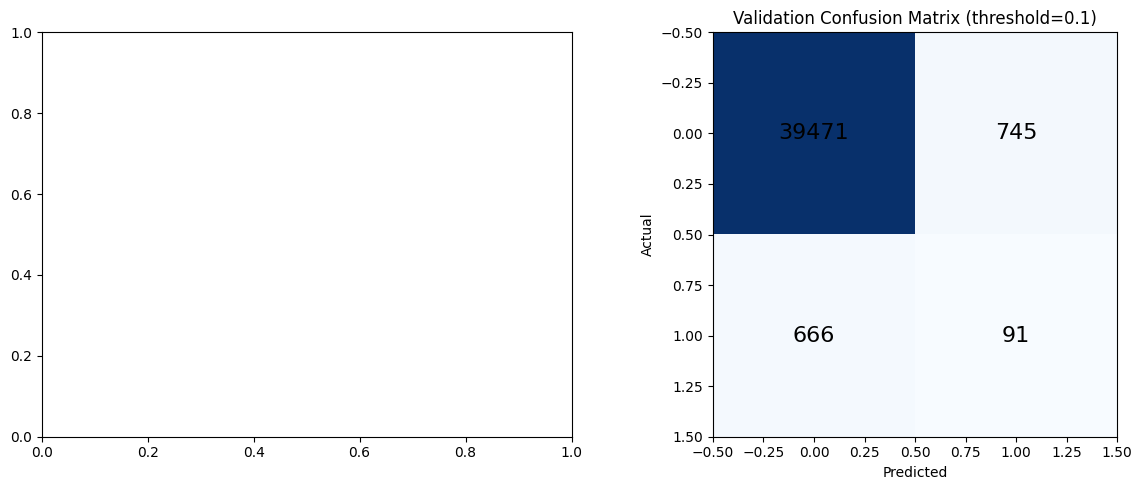


=== VALIDATION METRICS ===
Threshold: 0.2
Precision: 0.1466
Recall: 0.0661


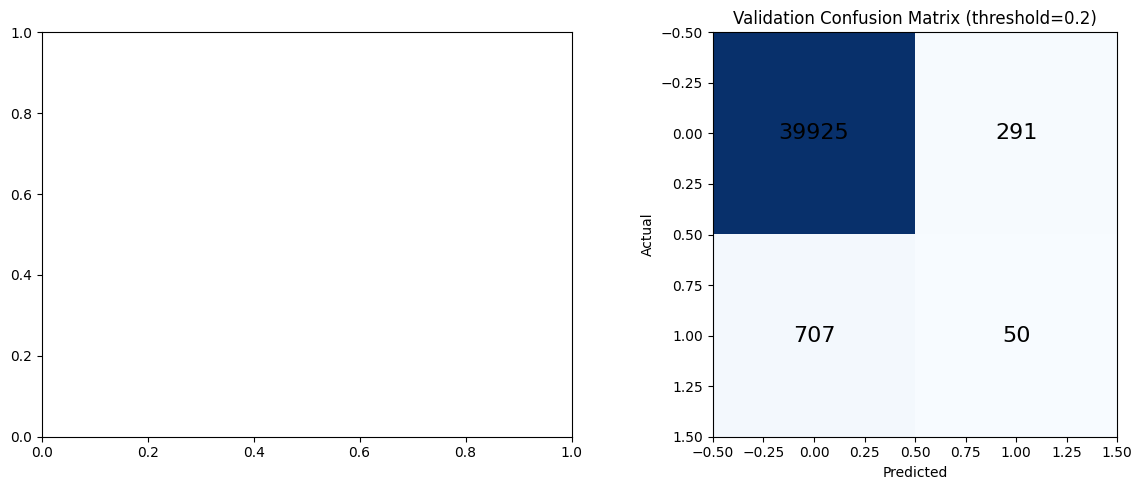


=== VALIDATION METRICS ===
Threshold: 0.3
Precision: 0.1771
Recall: 0.0410


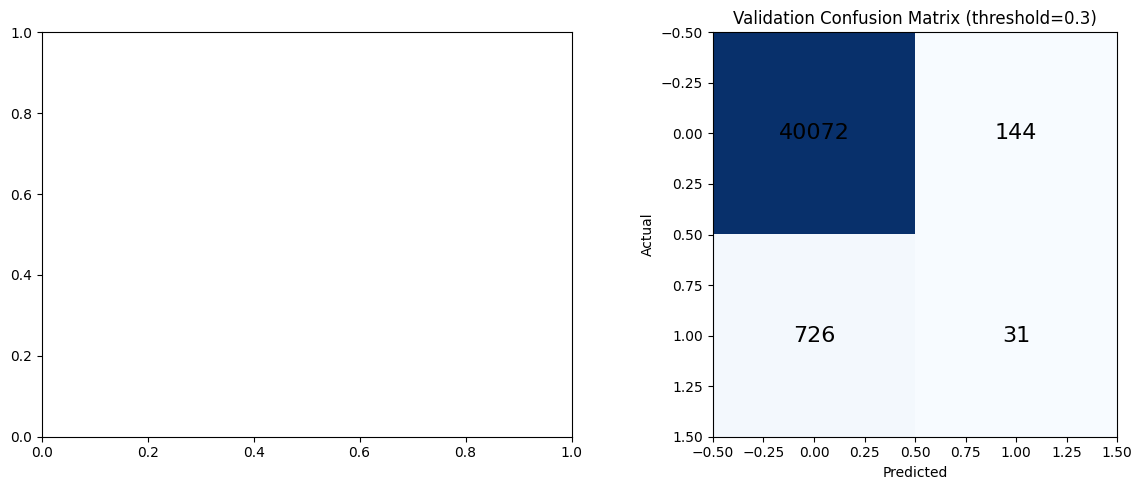


=== VALIDATION METRICS ===
Threshold: 0.4
Precision: 0.2778
Recall: 0.0198


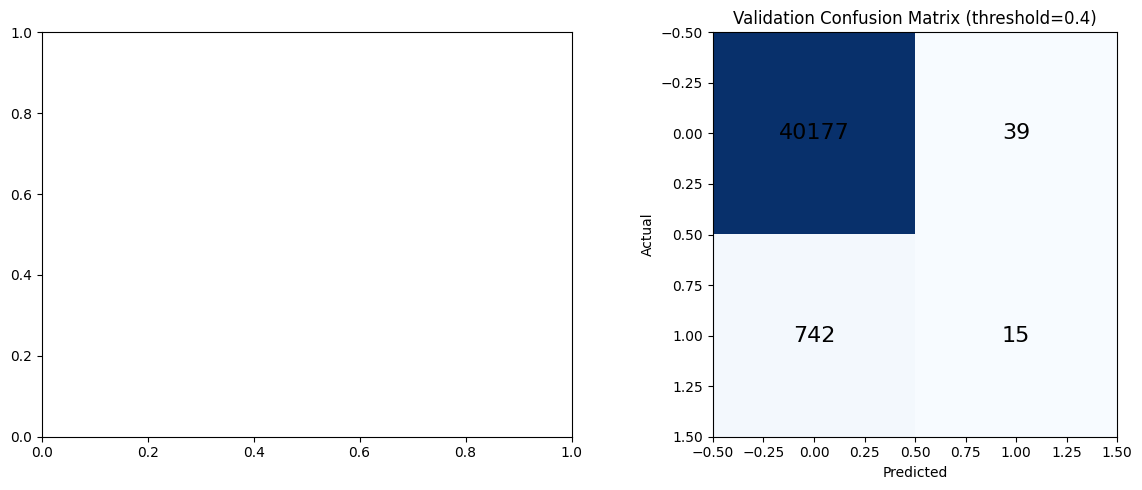


=== VALIDATION METRICS ===
Threshold: 0.5
Precision: 0.3030
Recall: 0.0132


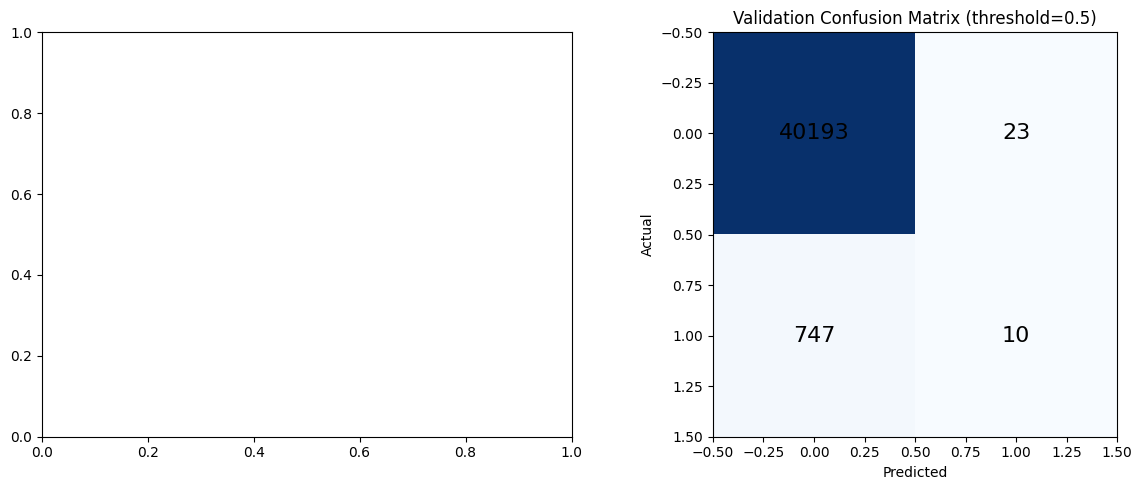

In [25]:
thresholds = [.03, .04, .05, .06, .08, .1, .2, .3, .4, .5]

for prediction_threshold in thresholds:

    # Get probability predictions
    y_train_proba = best_model.predict_proba(X_train)[:, 1]
    y_val_proba = best_model.predict_proba(X_val)[:, 1]

    # Apply custom threshold to get binary predictions
    y_train_pred = (y_train_proba >= prediction_threshold).astype(int)
    y_val_pred = (y_val_proba >= prediction_threshold).astype(int)

    # Metrics
    print("\n=== VALIDATION METRICS ===")
    print(f"Threshold: {prediction_threshold}")
    print(f"Precision: {precision_score(y_val, y_val_pred, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_val, y_val_pred, zero_division=0):.4f}")

    # Confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm_val = confusion_matrix(y_val, y_val_pred)

    im2 = axes[1].imshow(cm_val, cmap='Blues')
    axes[1].set_title(f'Validation Confusion Matrix (threshold={prediction_threshold})')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    for i in range(2):
        for j in range(2):
            axes[1].text(j, i, cm_val[i, j], ha='center', va='center', fontsize=16)

    plt.tight_layout()
    plt.show()


Top 10 Most Important Features:
    feature  importance  relative_strength
     ema_20    0.068664         100.000000
         ad    0.050676          73.801956
     sma_20    0.025224          36.735622
     ema_10    0.022734          33.108315
        obv    0.022374          32.584965
  bb_middle    0.018849          27.451220
   bb_lower    0.018291          26.638704
 ad_slope_5    0.016357          23.821617
macd_signal    0.012810          18.656673
 ad_slope_1    0.012772          18.600885


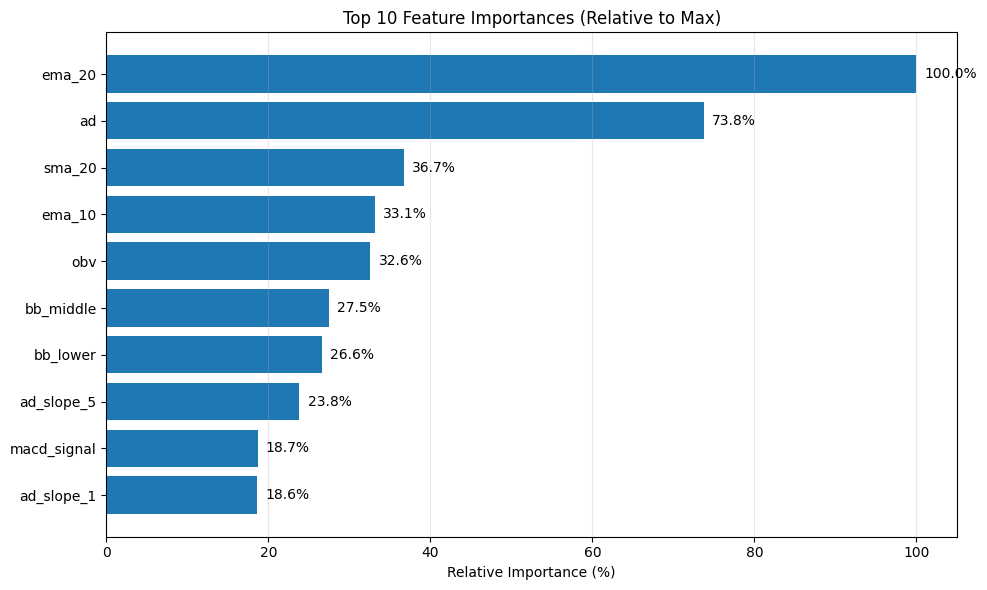

In [15]:
# Feature importance analysis
import pandas as pd

# Get feature importances from best model
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 10 features
top_10 = feature_importance.head(10).copy()

# Calculate relative strength (normalize to max = 100)
top_10['relative_strength'] = (top_10['importance'] / top_10['importance'].max()) * 100

print("Top 10 Most Important Features:")
print(top_10.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top_10)), top_10['relative_strength'])
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['feature'])
ax.set_xlabel('Relative Importance (%)')
ax.set_title('Top 10 Feature Importances (Relative to Max)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (imp, rel) in enumerate(zip(top_10['importance'], top_10['relative_strength'])):
    ax.text(rel + 1, i, f'{rel:.1f}%', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# Log everything to MLflow
import mlflow
import mlflow.xgboost
from datetime import datetime
from sklearn.metrics import precision_recall_curve, average_precision_score

# Set remote MLflow tracking server
mlflow.set_tracking_uri("http://z440.lan:5000")

# Set experiment
mlflow.set_experiment("ml_models")

# Calculate AUCPR
precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_proba)
precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_proba)
aucpr_train = average_precision_score(y_train, y_train_proba)
aucpr_val = average_precision_score(y_val, y_val_proba)

# Start run
run_name = f"{target_column}_thresh{prediction_threshold}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
with mlflow.start_run(run_name=run_name):
    
    # Log parameters
    mlflow.log_params(bayes_search.best_params_)
    mlflow.log_param("target_column", target_column)
    mlflow.log_param("prediction_threshold", prediction_threshold)
    mlflow.log_param("train_size", len(train_df))
    mlflow.log_param("val_size", len(val_df))
    mlflow.log_param("num_features", len(feature_cols))
    mlflow.log_param("device", device)
    mlflow.log_param("tree_method", tree_method)
    mlflow.log_param("optimization_method", "BayesSearchCV")
    mlflow.log_param("optimization_metric", "precision")
    
    # Log metrics - Training (using threshold-based predictions)
    mlflow.log_metric("train_accuracy", accuracy_score(y_train, y_train_pred))
    mlflow.log_metric("train_precision", precision_score(y_train, y_train_pred, zero_division=0))
    mlflow.log_metric("train_recall", recall_score(y_train, y_train_pred, zero_division=0))
    mlflow.log_metric("train_f1", f1_score(y_train, y_train_pred, zero_division=0))
    mlflow.log_metric("train_roc_auc", roc_auc_train)
    mlflow.log_metric("train_aucpr", aucpr_train)
    
    # Log metrics - Validation (using threshold-based predictions)
    mlflow.log_metric("val_accuracy", accuracy_score(y_val, y_val_pred))
    mlflow.log_metric("val_precision", precision_score(y_val, y_val_pred, zero_division=0))
    mlflow.log_metric("val_recall", recall_score(y_val, y_val_pred, zero_division=0))
    mlflow.log_metric("val_f1", f1_score(y_val, y_val_pred, zero_division=0))
    mlflow.log_metric("val_roc_auc", roc_auc_val)
    mlflow.log_metric("val_aucpr", aucpr_val)
    mlflow.log_metric("cv_best_precision", bayes_search.best_score_)
    
    # Log model
    mlflow.xgboost.log_model(best_model, "model")
    
    # Log ROC curve
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr_train, tpr_train, label=f'Train (AUC = {roc_auc_train:.4f})', linewidth=2)
    ax.plot(fpr_val, tpr_val, label=f'Val (AUC = {roc_auc_val:.4f})', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {target_column}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    mlflow.log_figure(fig, "roc_curve.png")
    plt.close()
    
    # Log Precision-Recall curve
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall_train, precision_train, label=f'Train (AUCPR = {aucpr_train:.4f})', linewidth=2)
    ax.plot(recall_val, precision_val, label=f'Val (AUCPR = {aucpr_val:.4f})', linewidth=2)
    baseline = sum(y_train == 1) / len(y_train)
    ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline ({baseline:.4f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curve - {target_column}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    mlflow.log_figure(fig, "precision_recall_curve.png")
    plt.close()
    
    # Log probability distribution with threshold line (validation only)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(y_val_proba[y_val == 0], bins=50, alpha=0.7, label='Val Negative', density=True)
    ax.hist(y_val_proba[y_val == 1], bins=50, alpha=0.7, label='Val Positive', density=True)
    ax.axvline(x=prediction_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({prediction_threshold})')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.set_title(f'Probability Distribution (Validation, threshold={prediction_threshold})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    mlflow.log_figure(fig, "probability_distribution.png")
    plt.close()
    
    # Log confusion matrices with threshold in title
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_val = confusion_matrix(y_val, y_val_pred)
    
    axes[0].imshow(cm_train, cmap='Blues')
    axes[0].set_title(f'Training Confusion Matrix (threshold={prediction_threshold})')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm_train[i, j], ha='center', va='center', fontsize=16)
    
    axes[1].imshow(cm_val, cmap='Blues')
    axes[1].set_title(f'Validation Confusion Matrix (threshold={prediction_threshold})')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    for i in range(2):
        for j in range(2):
            axes[1].text(j, i, cm_val[i, j], ha='center', va='center', fontsize=16)
    
    plt.tight_layout()
    mlflow.log_figure(fig, "confusion_matrices.png")
    plt.close()
    
    # Log feature importance
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(top_10)), top_10['relative_strength'])
    ax.set_yticks(range(len(top_10)))
    ax.set_yticklabels(top_10['feature'])
    ax.set_xlabel('Relative Importance (%)')
    ax.set_title('Top 10 Feature Importances')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    for i, rel in enumerate(top_10['relative_strength']):
        ax.text(rel + 1, i, f'{rel:.1f}%', va='center')
    mlflow.log_figure(fig, "feature_importance.png")
    plt.close()
    
    # Log feature importance as CSV
    feature_importance.to_csv('feature_importance.csv', index=False)
    mlflow.log_artifact('feature_importance.csv')
    
    # Log classification reports as text
    train_report = classification_report(y_train, y_train_pred, zero_division=0)
    val_report = classification_report(y_val, y_val_pred, zero_division=0)
    
    with open('train_classification_report.txt', 'w') as f:
        f.write(f"Prediction Threshold: {prediction_threshold}\n")
        f.write("=" * 50 + "\n\n")
        f.write(train_report)
    mlflow.log_artifact('train_classification_report.txt')
    
    with open('val_classification_report.txt', 'w') as f:
        f.write(f"Prediction Threshold: {prediction_threshold}\n")
        f.write("=" * 50 + "\n\n")
        f.write(val_report)
    mlflow.log_artifact('val_classification_report.txt')
    
    # Log target distributions
    mlflow.log_param("train_target_0", int((y_train == 0).sum()))
    mlflow.log_param("train_target_1", int((y_train == 1).sum()))
    mlflow.log_param("val_target_0", int((y_val == 0).sum()))
    mlflow.log_param("val_target_1", int((y_val == 1).sum()))
    
    run_id = mlflow.active_run().info.run_id
    print(f"\nLogged to MLflow remote server!")
    print(f"Tracking URI: http://z440.lan:5000")
    print(f"Run ID: {run_id}")
    print(f"Experiment: ml_models")
    print(f"Run name: {run_name}")
    print(f"View at: http://z440.lan:5000/#/experiments")
    print(f"\nKey Metrics (threshold={prediction_threshold}):")
    print(f"  Train - Precision: {precision_score(y_train, y_train_pred, zero_division=0):.4f}, Recall: {recall_score(y_train, y_train_pred, zero_division=0):.4f}, F1: {f1_score(y_train, y_train_pred, zero_division=0):.4f}")
    print(f"  Val   - Precision: {precision_score(y_val, y_val_pred, zero_division=0):.4f}, Recall: {recall_score(y_val, y_val_pred, zero_division=0):.4f}, F1: {f1_score(y_val, y_val_pred, zero_division=0):.4f}")
    print(f"  Train - ROC-AUC: {roc_auc_train:.4f}, AUCPR: {aucpr_train:.4f}")
    print(f"  Val   - ROC-AUC: {roc_auc_val:.4f}, AUCPR: {aucpr_val:.4f}")